In [ ]:
pip install pandas matplotlib scikit-learn statsmodels

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import numpy as np

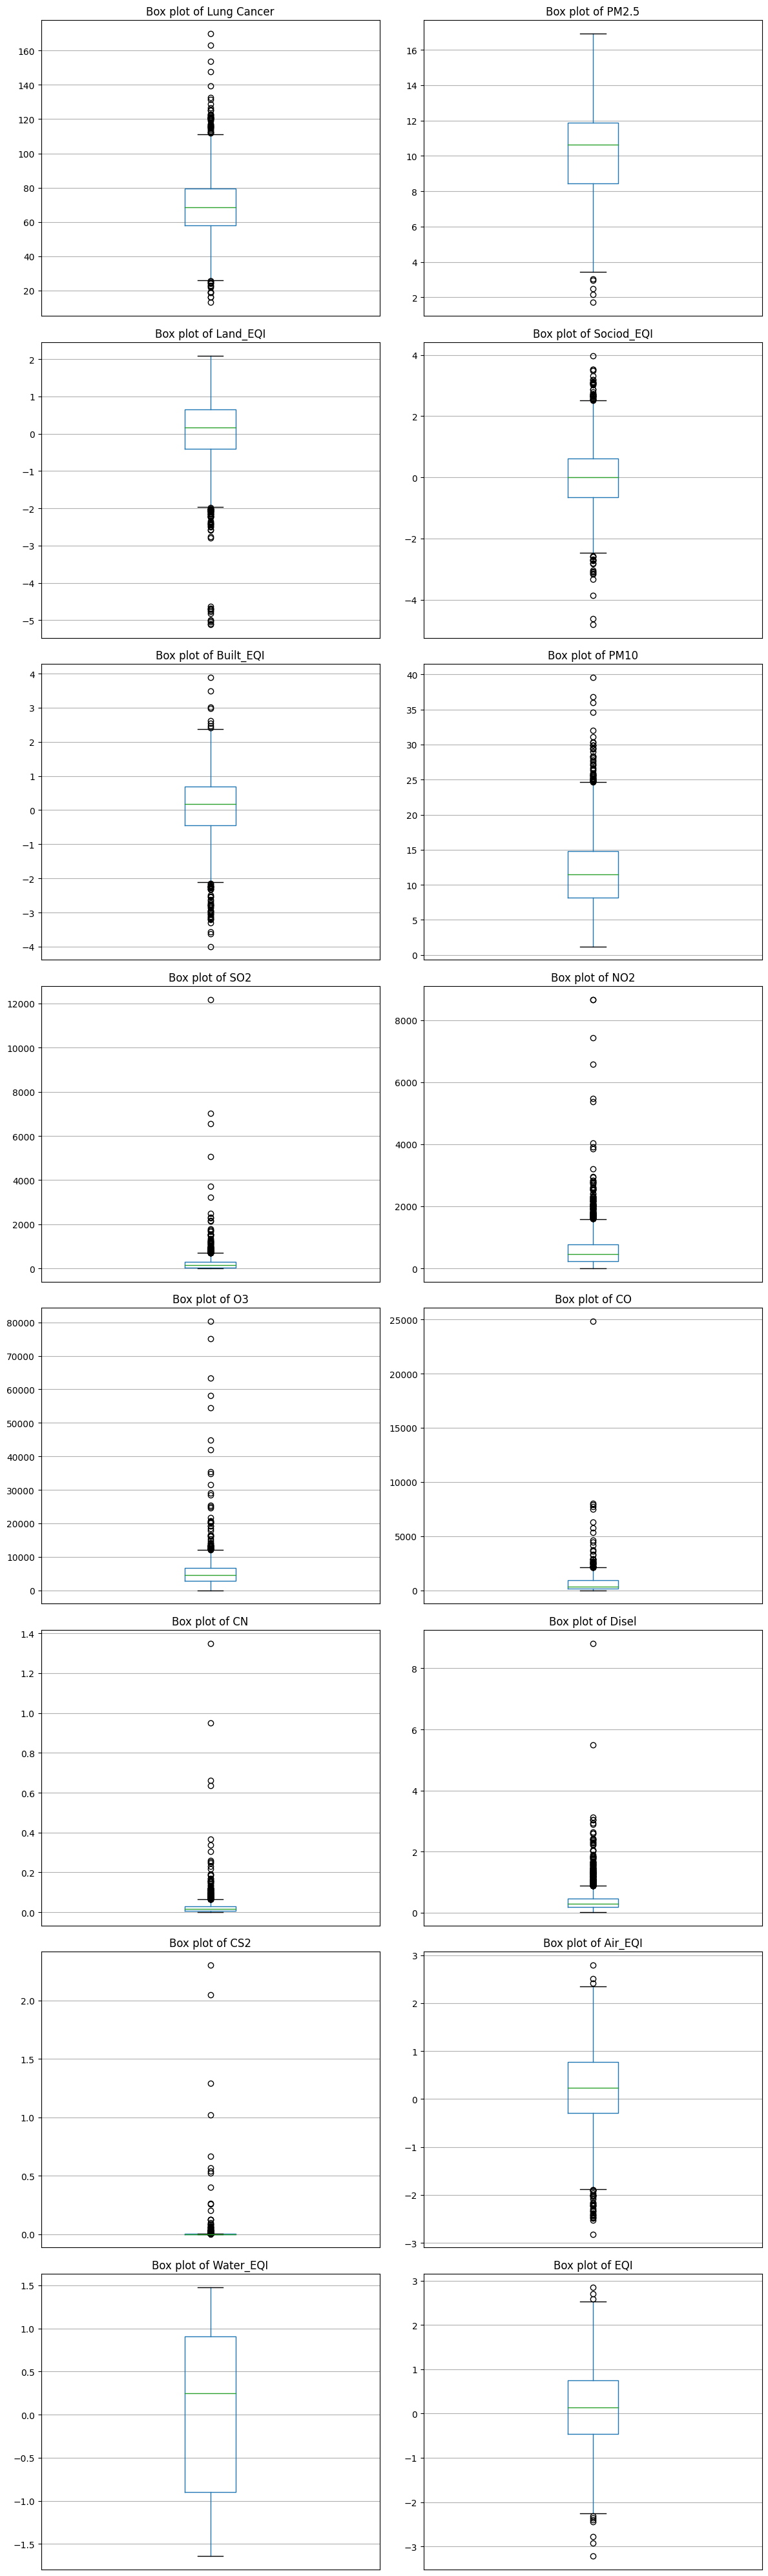

       Lung Cancer        PM2.5     Land_EQI   Sociod_EQI    Built_EQI  \
count  2602.000000  2602.000000  2602.000000  2602.000000  2602.000000   
mean     69.170907    10.125242     0.033273     0.009265     0.079856   
std      17.418000     2.341308     0.845161     0.991924     0.863834   
min      12.900000     1.700000    -5.115808    -4.809990    -3.992723   
25%      58.000000     8.452500    -0.400679    -0.649570    -0.438983   
50%      68.600000    10.650000     0.174875     0.004630     0.179253   
75%      79.400000    11.860000     0.647736     0.617387     0.689862   
max     169.900000    16.910000     2.094526     3.979472     3.883786   

              PM10           SO2          NO2            O3            CO  \
count  2602.000000   2602.000000  2602.000000   2602.000000   2602.000000   
mean     11.905211    233.540202   592.968907   5125.998213    604.816897   
std       4.843881    407.248302   571.236358   4305.516001    798.759705   
min       1.220000      1

In [ ]:
file_path = '/content/lungcancerdata.csv'
df = pd.read_csv(file_path)
df.dropna(inplace=True)

# Plot Box Plots for Each Numeric Column Separately
numeric_columns = df.select_dtypes(include='number').columns  # Select numeric columns only

num_cols = len(numeric_columns)
num_rows = (num_cols + 1) // 2  # Calculate number of rows needed

plt.figure(figsize=(12, num_rows * 5))  # Adjust figure size based on number of rows

# Iterate through each numeric column in the DataFrame
for i, col in enumerate(numeric_columns):
    plt.subplot(num_rows, 2, i + 1)  # Create subplots dynamically
    df.boxplot(column=col)
    plt.title(f'Box plot of {col}')
    plt.xticks([])  # Remove xticks for better layout

plt.tight_layout()
plt.show()

# Display Summary Statistics
summary_stats = df.describe()
print(summary_stats)

In [ ]:
df

,County,State,Lung Cancer,PM2.5,Land_EQI,Sociod_EQI,Built_EQI,PM10,SO2,NO2,O3,CO,CN,Disel,CS2,Air_EQI,Water_EQI,EQI
0,Autauga,AL,73.9,12.06,-0.706591,0.670436,-0.497301,15.07,10.661088,123.657648,522.38,4.463225,0.054815,0.388556,0.008080,0.955385,-1.109728,0.00
1,Baldwin,AL,68.4,11.12,-1.084299,0.553073,0.401585,19.99,17.146847,247.742253,540.79,12.875833,0.021069,0.428278,0.001090,0.717964,-0.565911,0.20
2,Barbour,AL,76.1,12.36,-1.281470,-1.236294,0.048854,15.77,23.257118,183.193624,896.42,19.620539,0.014027,0.199725,0.000513,0.131007,-0.978090,-0.95
3,Bibb Cou,AL,86.4,12.24,-0.827410,-0.600018,-1.290857,14.92,7.630953,127.779935,563.48,2.951976,0.009613,0.211741,0.000225,0.065289,-0.968173,-1.09
4,Blount C,AL,73.1,12.97,-0.622934,0.296509,-1.262740,17.90,8.913795,95.198094,561.94,9.362215,0.022128,0.300100,0.000429,0.402194,-0.718645,-0.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2597,Sweetwat,WY,45.3,6.40,0.329106,0.832869,1.309324,11.26,51.633922,342.108999,1703.31,422.322102,0.007201,0.204528,0.000227,-0.039545,1.130375,1.09
2598,Teton Co,WY,22.6,6.67,0.316508,1.812128,2.418939,10.40,39.036416,322.610755,3614.23,3754.236317,0.005966,0.080880,0.000114,-0.557297,1.071576,1.67
2599,Uinta Co,WY,37.1,6.57,0.253324,0.715908,1.134188,8.35,65.490741,529.309963,3467.05,1109.005206,0.002770,0.089568,0.000245,-0.814369,1.162652,0.69
2600,Washakie,WY,51.1,6.33,0.151024,-0.067995,0.728454,7.21,157.728659,284.452099,2819.26,199.103987,0.011684,0.157553,0.000184,-0.244298,1.004629,0.38


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:465: UserWarning: X does not have valid feature n

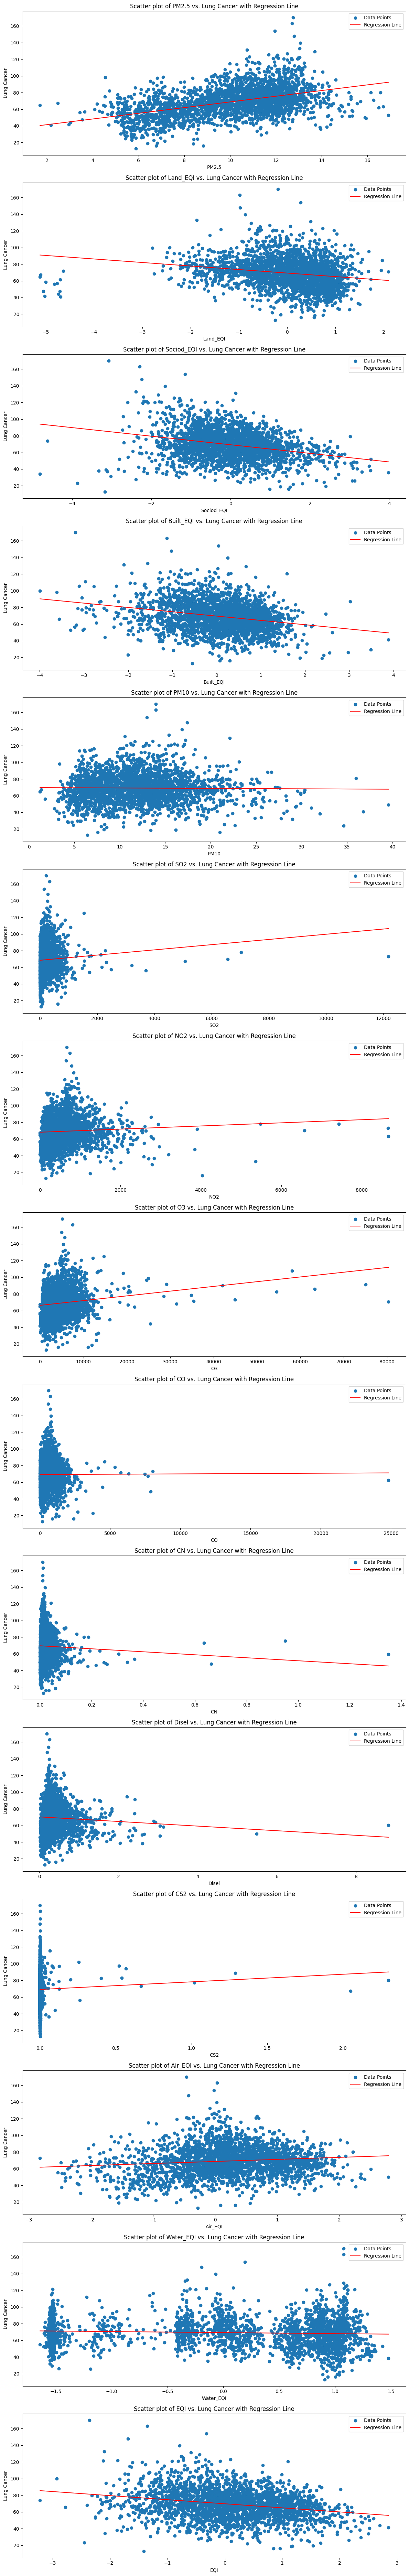

In [ ]:
lung_cancer_column = 'Lung Cancer'
columns = [col for col in numeric_columns if col != lung_cancer_column]

plt.figure(figsize=(12, len(columns) * 5))

for i, col in enumerate(columns):
    # Create subplot
    plt.subplot(len(columns), 1, i + 1)

    # Scatter plot
    plt.scatter(df[col], df[lung_cancer_column], label='Data Points')

    # Fit a linear regression model
    X = df[[col]]
    y = df[lung_cancer_column]
    model = LinearRegression()
    model.fit(X, y)

    # Create predictions
    x_vals = np.linspace(df[col].min(), df[col].max(), 100).reshape(-1, 1)
    y_vals = model.predict(x_vals)

    # Plot the regression line
    plt.plot(x_vals, y_vals, color='red', label='Regression Line')

    plt.xlabel(col)
    plt.ylabel(lung_cancer_column)
    plt.title(f'Scatter plot of {col} vs. {lung_cancer_column} with Regression Line')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
df_cleaned = df.dropna()

# Linear Regression using statsmodels
# Define the predictor variables (X) and the target variable (y)
X = df_cleaned[numeric_columns].drop(columns=[lung_cancer_column])
y = df_cleaned[lung_cancer_column]

# Add a constant to the predictor variables (required by statsmodels)
X = sm.add_constant(X)

# Split the data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the linear regression model on the training data
model = sm.OLS(y_train, X_train).fit()

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model on the test data
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error (Test Data): {mse}')
print(f'R-squared (Test Data): {r2}')

# Display the summary of the model, which includes p-values
print(model.summary())

Mean Squared Error (Test Data): 184.9691214793518
R-squared (Test Data): 0.3504797176413683
                            OLS Regression Results                            
Dep. Variable:            Lung Cancer   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     72.96
Date:                Wed, 04 Sep 2024   Prob (F-statistic):          4.61e-178
Time:                        19:28:24   Log-Likelihood:                -8468.1
No. Observations:                2081   AIC:                         1.697e+04
Df Residuals:                    2065   BIC:                         1.706e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------